In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_excel("data/Dataset_Assignment_1.xlsx", sheet_name=0)
df["Gender"] = df["Gender"].map({"Male": 0, "Female": 1})
df["Accommodation_Class"] = df["Accommodation_Class"].map({"Rented": 0, "Non_Rented": 1})

ID                     0
DTI                    0
FOIR                   0
LTV                    0
Age                    0
OldEmi                 0
Gender                 0
Accommodation_Class    0
Decision               0
dtype: int64


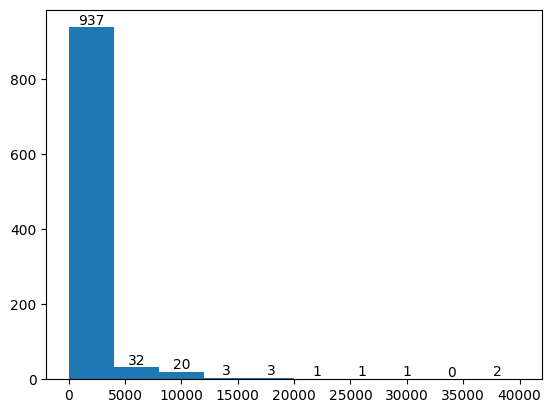

Male : Female = 99:901
Ratio = 0.11
Rented : Non Rented = 485:515
Ratio = 0.94


In [2]:
print(df.isnull().sum())
features = ["DTI", "FOIR", "LTV", "Age"]

counts, bins, patches = plt.hist(df["OldEmi"])
for count, patch in zip(counts, patches):
    plt.text(
        patch.get_x() + patch.get_width() / 2,
        count,
        int(count),
        ha="center",
        va="bottom",
    )
plt.savefig("pictures/table1_OldEmi.pdf", bbox_inches="tight")
plt.show()

counts = df["Gender"].value_counts()
male = counts[0]#male
female = counts[1]
print(f"Male : Female = {male}:{female}")
print(f"Ratio = {male/female:.2f}")

counts = df["Accommodation_Class"].value_counts()
male = counts[0] #rented
female = counts[1]
print(f"Rented : Non Rented = {male}:{female}")
print(f"Ratio = {male/female:.2f}")


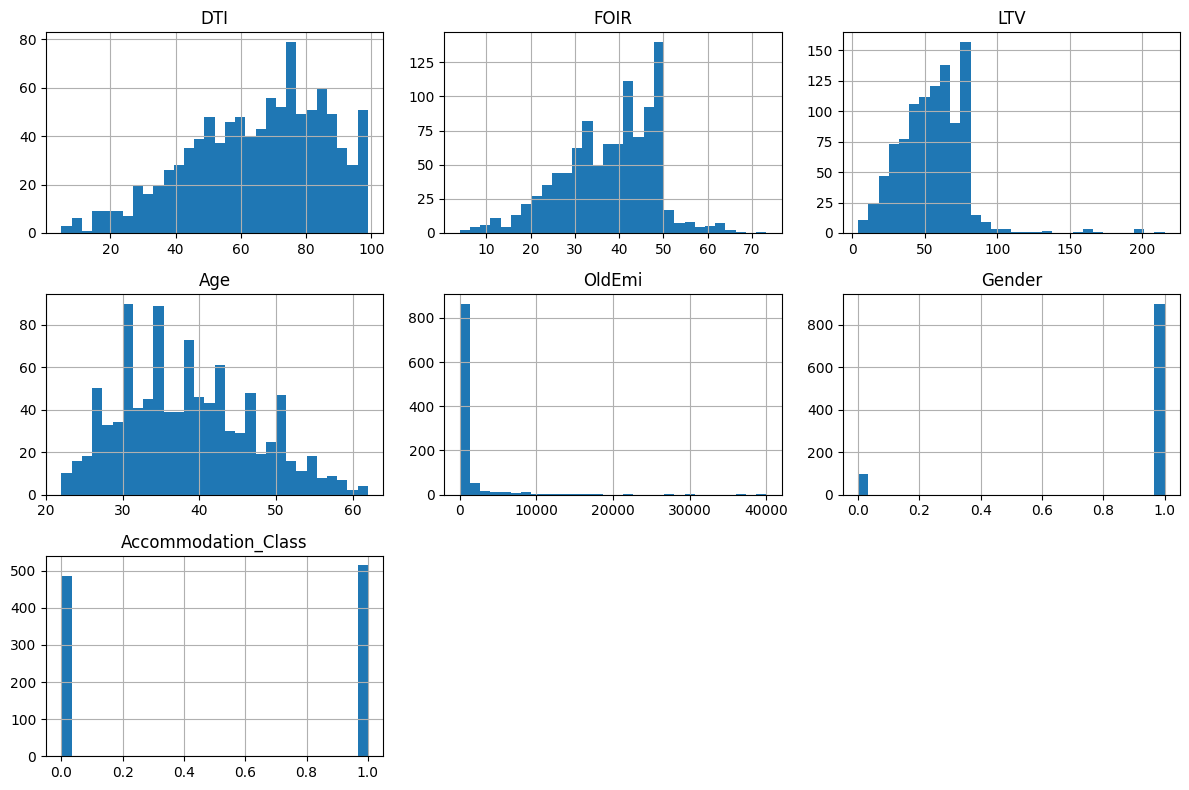

In [3]:
features = ["DTI", "FOIR", "LTV", "Age", "OldEmi", "Gender", "Accommodation_Class"]

df[features].hist(figsize=(12, 8), bins=30)
plt.tight_layout()
plt.savefig("pictures/histograms.pdf", bbox_inches = "tight")


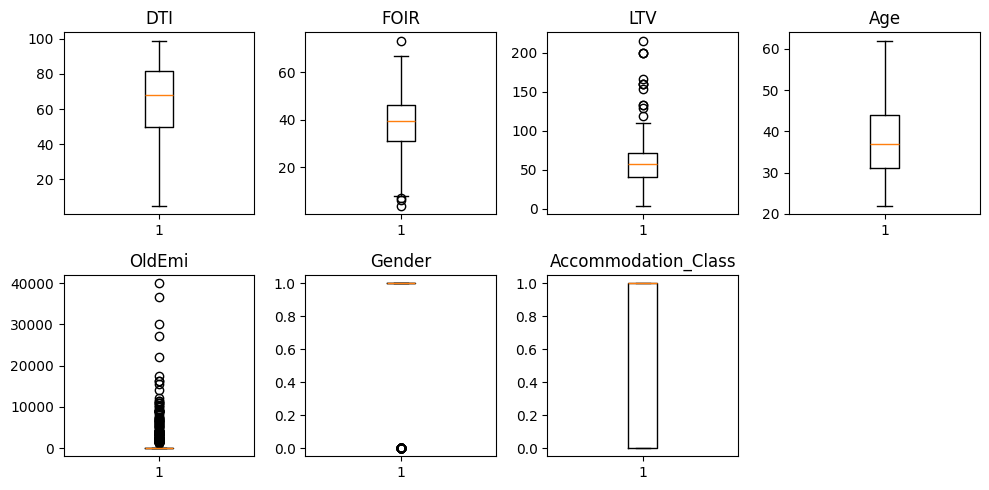

In [4]:
plt.figure(figsize=(10,5))

for i, feature in enumerate(features):
    plt.subplot(2,4,i+1)
    plt.boxplot(df[feature])
    plt.title(feature)

plt.tight_layout()
plt.savefig("pictures/boxplots.pdf", bbox_inches = "tight")

In [5]:
print(pd.crosstab(df["Gender"], df["Decision"], normalize="index"))

Decision   Approve    Reject
Gender                      
0         0.828283  0.171717
1         0.799112  0.200888


In [6]:
print(pd.crosstab(df["Accommodation_Class"], df["Decision"], normalize="index"))

Decision              Approve    Reject
Accommodation_Class                    
0                    0.845361  0.154639
1                    0.761165  0.238835


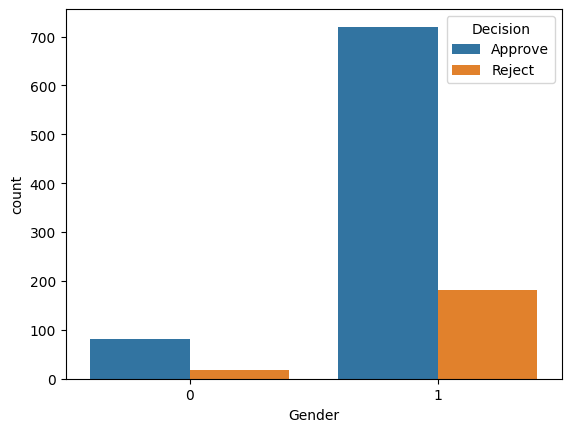

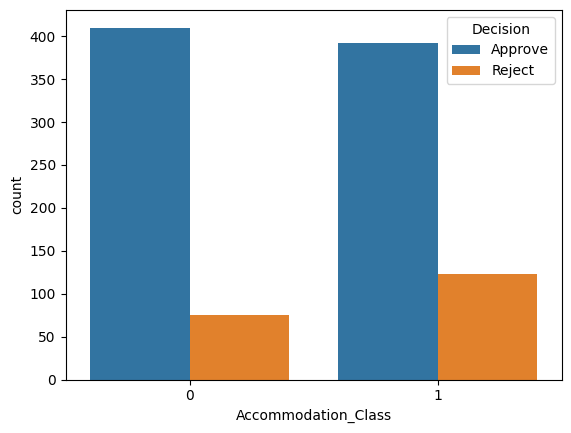

In [7]:

sns.countplot(data=df, x="Gender", hue="Decision")
plt.show()

sns.countplot(data=df, x="Accommodation_Class", hue="Decision")
plt.show()

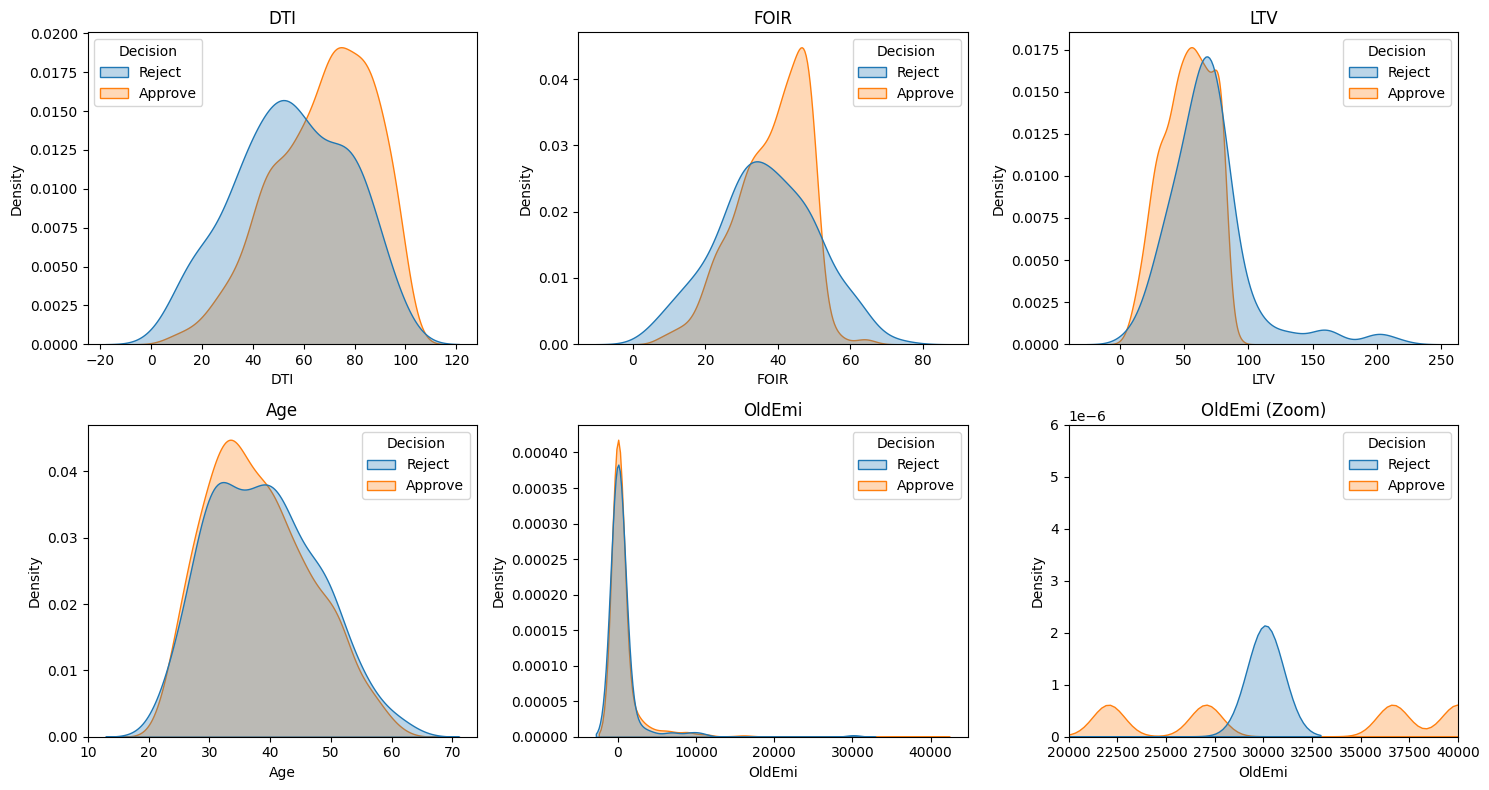

In [8]:

features = ["DTI", "FOIR", "LTV", "Age", "OldEmi"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

# First five KDE plots
for i, feature in enumerate(features):
    sns.kdeplot(
        data=df,
        x=feature,
        hue="Decision",
        common_norm=False,
        fill=True,
        alpha=0.3,
        ax=axes[i]
    )

    axes[i].set_title(feature)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Density")

# Sixth plot: zoomed OldEmi
sns.kdeplot(
    data=df,
    x="OldEmi",
    hue="Decision",
    common_norm=False,
    fill=True,
    alpha=0.3,
    ax=axes[5]
)

axes[5].set_xlim(20000, 40000)
axes[5].set_ylim(0, 0.000006)
axes[5].set_title("OldEmi (Zoom)")
axes[5].set_xlabel("OldEmi")
axes[5].set_ylabel("Density")

plt.tight_layout()
plt.savefig("pictures/densities.pdf", bbox_inches = "tight")
plt.show()

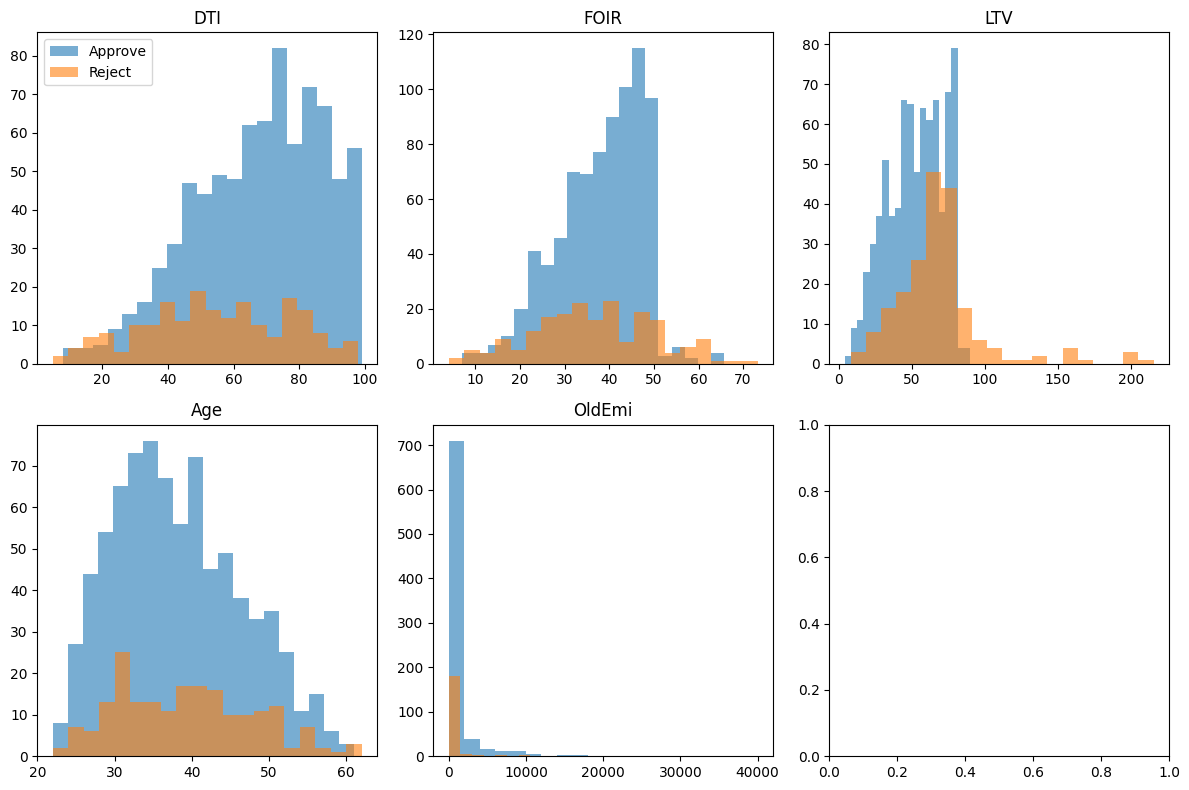

In [9]:
features = ["DTI", "FOIR", "LTV", "Age", "OldEmi"]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for ax, feature in zip(axes.flat, features):

    ax.hist(
        df[df["Decision"]=="Approve"][feature],
        bins=20,
        alpha=0.6,
        label="Approve"
    )

    ax.hist(
        df[df["Decision"]=="Reject"][feature],
        bins=20,
        alpha=0.6,
        label="Reject"
    )

    ax.set_title(feature)

axes[0,0].legend()
plt.tight_layout()
plt.show()

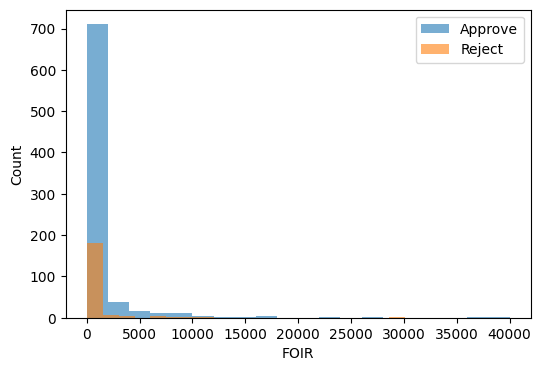

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.hist(df[df["Decision"]=="Approve"]["OldEmi"],
         bins=20,
         alpha=0.6,
         label="Approve")

plt.hist(df[df["Decision"]=="Reject"]["OldEmi"],
         bins=20,
         alpha=0.6,
         label="Reject")

plt.xlabel("FOIR")
plt.ylabel("Count")
plt.legend()
plt.show()